# Flu Hospitalization Forecasting Demo

This notebook demonstrates the XGBoost-based flu hospitalization forecasting pipeline using data up to November 2, 2024.

## Pipeline Overview
1. **Data Loading**: Fetch data from CDC FluSight repository with temporal cutoff
2. **Feature Engineering**: Create lag features, rolling statistics, and temporal features
3. **Model Training**: Train XGBoost model with walk-forward validation
4. **Forecasting**: Generate 4-week ahead predictions using recursive forecasting
5. **Evaluation**: Assess model performance with multiple metrics


## 1. Setup and Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import json
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Import our pipeline components
from data_loader import FluDataLoader
from feature_engineering import FeatureEngineer
from model import FluForecastingModel
from train import FluModelTrainer
from predict import FluForecastGenerator
from evaluate import ModelEvaluator
from pipeline import FluForecastingPipeline
import config

print("Imports completed successfully!")


Imports completed successfully!


In [2]:
# Load data with November 2, 2024 cutoff
cutoff_date = "2024-11-02"
print(f"Loading data up to {cutoff_date}...")

loader = FluDataLoader()
data = loader.load_and_preprocess(cutoff_date)

print(f"\nData loaded successfully!")
print(f"Shape: {data.shape}")
print(f"Date range: {data['date'].min()} to {data['date'].max()}")
print(f"Locations: {data['location'].nunique()}")
print(f"Total hospitalizations: {data['value'].sum():,}")


Loading data up to 2024-11-02...
Data filtered to cutoff date 2024-11-02
Date range: 2022-02-05 00:00:00 to 2024-11-02 00:00:00
Number of records: 7632
Number of locations: 53
Data validation completed successfully

Data Summary:
date_range: (Timestamp('2022-02-05 00:00:00'), Timestamp('2024-11-02 00:00:00'))
total_records: 7632
unique_locations: 53
total_hospitalizations: 1089517.0
avg_weekly_hospitalizations: 143.43299104791996
missing_values: {'date': 0, 'location': 0, 'location_name': 0, 'value': 36, 'weekly_rate': 36}

Data loaded successfully!
Shape: (7632, 5)
Date range: 2022-02-05 00:00:00 to 2024-11-02 00:00:00
Locations: 53
Total hospitalizations: 1,089,517.0


## 2. Data Loading and Exploration


In [3]:
# Display basic data information
print("Data Overview:")
print("=" * 50)
print(f"Total records: {len(data):,}")
print(f"Date range: {data['date'].min()} to {data['date'].max()}")
print(f"Number of locations: {data['location'].nunique()}")
print(f"Total hospitalizations: {data['value'].sum():,}")
print(f"Average weekly hospitalizations: {data['value'].mean():.1f}")

# Show sample data
print("\nSample data:")
print(data.head())

# Show location breakdown
print("\nLocation breakdown:")
location_counts = data.groupby('location')['value'].agg(['count', 'sum', 'mean']).round(1)
print(location_counts.head(10))


Data Overview:
Total records: 7,632
Date range: 2022-02-05 00:00:00 to 2024-11-02 00:00:00
Number of locations: 53
Total hospitalizations: 1,089,517.0
Average weekly hospitalizations: 143.4

Sample data:
        date location location_name  value  weekly_rate
0 2022-02-05       01       Alabama    5.0     0.096942
1 2022-02-05       02        Alaska    1.0     0.135111
2 2022-02-05       04       Arizona   35.0     0.461596
3 2022-02-05       05      Arkansas   16.0     0.518075
4 2022-02-05       06    California   30.0     0.076082

Location breakdown:
          count      sum   mean
location                       
01          144   7464.0   51.8
02          144   1006.0    7.0
04          144  19085.0  132.5
05          144   8073.0   56.1
06          144  40232.0  279.4
08          144   8186.0   56.8
09          144   6323.0   43.9
10          144   1084.0    7.5
11          144   1104.0    7.7
12          144  42472.0  294.9


## 3. Data Visualization


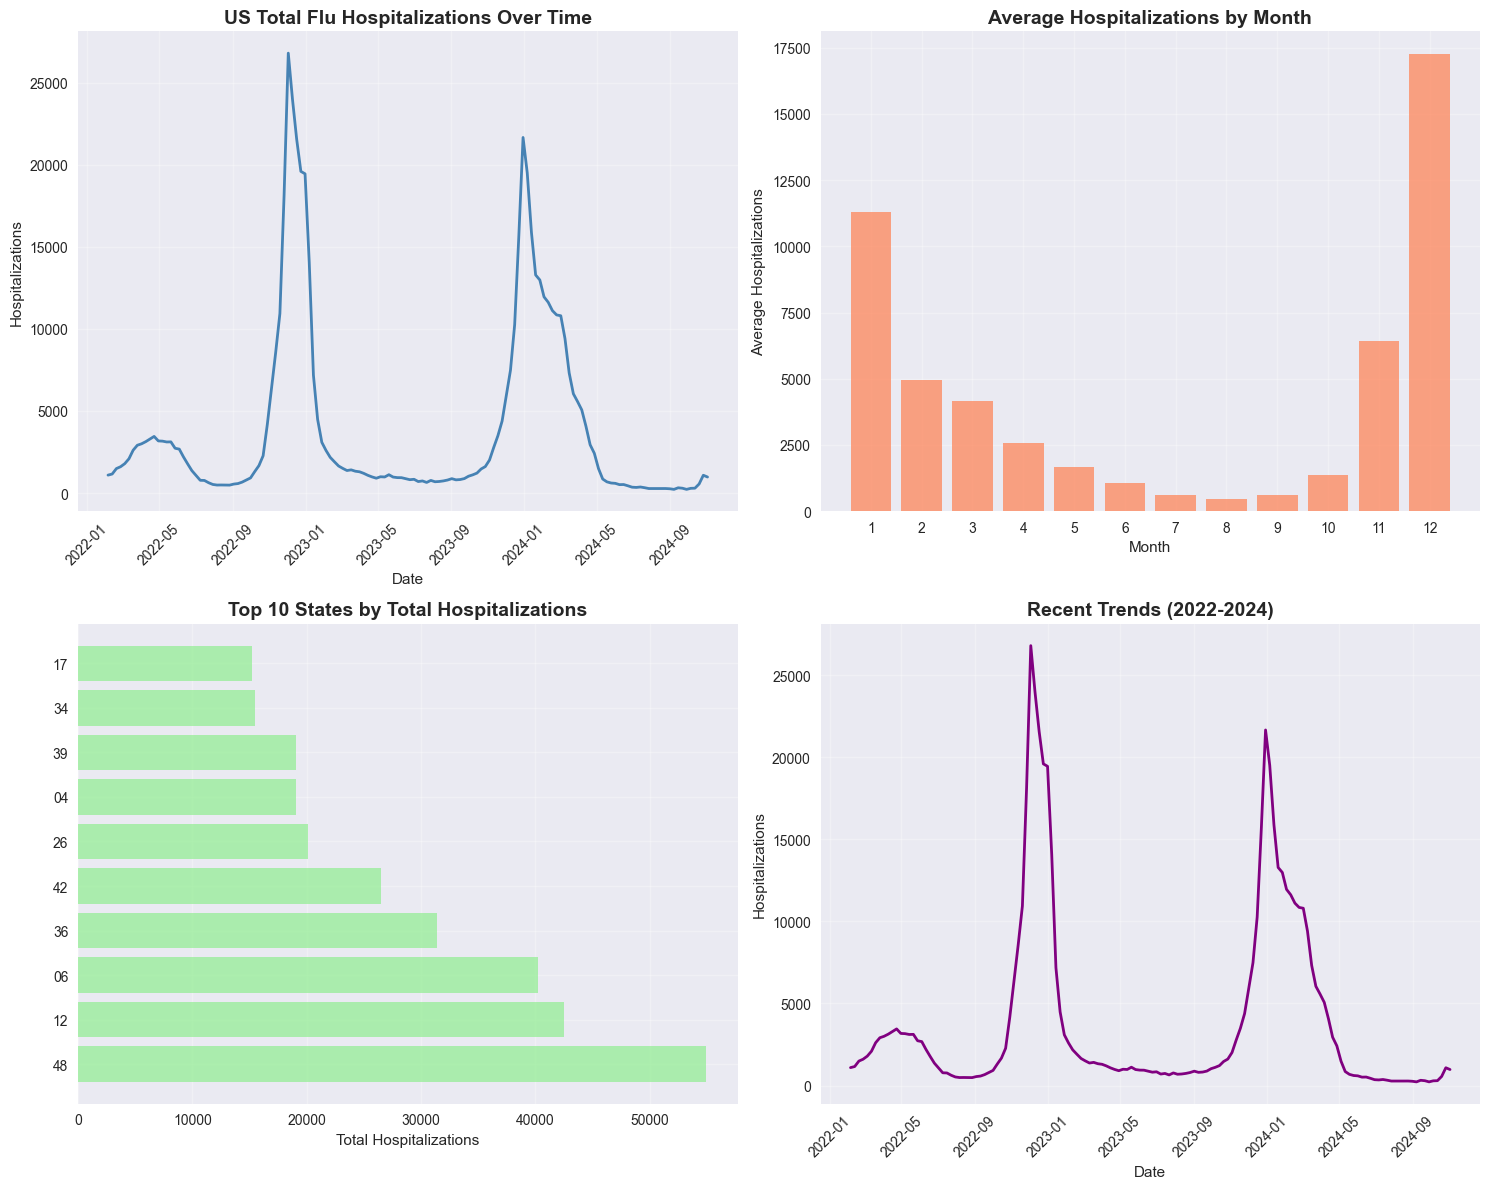

Key Statistics:
Peak month: 12 (avg: 17254 hospitalizations)
Lowest month: 8 (avg: 478 hospitalizations)
Peak-to-trough ratio: 36.1x


In [4]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Time series for US total
us_data = data[data['location'] == 'US'].copy()
us_data = us_data.sort_values('date')

axes[0, 0].plot(us_data['date'], us_data['value'], linewidth=2, color='steelblue')
axes[0, 0].set_title('US Total Flu Hospitalizations Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Hospitalizations')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# 2. Seasonal pattern
us_data['month'] = pd.to_datetime(us_data['date']).dt.month
monthly_avg = us_data.groupby('month')['value'].mean()

axes[0, 1].bar(monthly_avg.index, monthly_avg.values, color='coral', alpha=0.7)
axes[0, 1].set_title('Average Hospitalizations by Month', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Hospitalizations')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].grid(True, alpha=0.3)

# 3. Top states by total hospitalizations
state_totals = data[data['location'] != 'US'].groupby('location')['value'].sum().sort_values(ascending=False).head(10)
axes[1, 0].barh(range(len(state_totals)), state_totals.values, color='lightgreen', alpha=0.7)
axes[1, 0].set_title('Top 10 States by Total Hospitalizations', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Total Hospitalizations')
axes[1, 0].set_yticks(range(len(state_totals)))
axes[1, 0].set_yticklabels(state_totals.index)
axes[1, 0].grid(True, alpha=0.3)

# 4. Recent trends (last 2 years)
recent_data = data[data['date'] >= '2022-01-01']
if len(recent_data) > 0:
    recent_us = recent_data[recent_data['location'] == 'US'].sort_values('date')
    axes[1, 1].plot(recent_us['date'], recent_us['value'], linewidth=2, color='purple')
    axes[1, 1].set_title('Recent Trends (2022-2024)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Hospitalizations')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some key statistics
print("Key Statistics:")
print("=" * 30)
print(f"Peak month: {monthly_avg.idxmax()} (avg: {monthly_avg.max():.0f} hospitalizations)")
print(f"Lowest month: {monthly_avg.idxmin()} (avg: {monthly_avg.min():.0f} hospitalizations)")
print(f"Peak-to-trough ratio: {monthly_avg.max() / monthly_avg.min():.1f}x")


## 4. Feature Engineering


In [5]:
# Initialize feature engineer
feature_engineer = FeatureEngineer()

# Create features for the data
print("Creating features...")
data_with_features = feature_engineer.create_all_features(data)

print(f"Original features: {data.shape[1]}")
print(f"Features after engineering: {data_with_features.shape[1]}")
print(f"New features added: {data_with_features.shape[1] - data.shape[1]}")

# Show feature names
feature_columns = [col for col in data_with_features.columns if col not in data.columns]
print(f"\nNew features created:")
for i, feature in enumerate(feature_columns, 1):
    print(f"{i:2d}. {feature}")

# Show sample of engineered data
print(f"\nSample of engineered data:")
print(data_with_features[['date', 'location', 'value'] + feature_columns[:5]].head())

# Check for missing values in new features
missing_counts = data_with_features[feature_columns].isnull().sum()
if missing_counts.sum() > 0:
    print(f"\nMissing values in new features:")
    print(missing_counts[missing_counts > 0])
else:
    print(f"\nNo missing values in engineered features!")


Creating features...
Creating temporal features...
Creating lag features...
Creating rolling features...
Creating US-level features...
Creating interaction features...
Handling missing values...
Feature engineering completed. Final shape: (7632, 39)
Original features: 5
Features after engineering: 39
New features added: 34

New features created:
 1. year
 2. month
 3. week_of_year
 4. day_of_year
 5. week_sin
 6. week_cos
 7. month_sin
 8. month_cos
 9. day_sin
10. day_cos
11. value_lag_1
12. value_lag_2
13. value_lag_3
14. value_lag_4
15. value_lag_8
16. value_lag_12
17. value_rolling_mean_4
18. value_rolling_std_4
19. value_rolling_min_4
20. value_rolling_max_4
21. value_rolling_mean_8
22. value_rolling_std_8
23. value_rolling_min_8
24. value_rolling_max_8
25. value_trend_4w
26. us_total_lag_1
27. us_total_lag_2
28. us_total_lag_3
29. us_total_lag_4
30. us_total_rolling_mean_4
31. us_total_rolling_std_4
32. us_total_rolling_mean_8
33. us_total_rolling_std_8
34. recent_vs_historical



## 5. Model Training and Validation


In [6]:
# Initialize the pipeline
pipeline = FluForecastingPipeline()

# Run the complete pipeline
print("Running complete flu forecasting pipeline...")
print("=" * 50)

# Define parameters
target_locations = ['US', '06', '12', '48']  # US, CA, FL, TX
print(f"Target locations: {target_locations}")

# Run the pipeline
results = pipeline.run_full_pipeline(
    cutoff_date=cutoff_date,
    locations=target_locations,
    retrain=True,
    generate_forecasts=True,
    with_confidence=True
)

print("\nPipeline completed successfully!")
print("=" * 50)

# Display results summary
print("Results Summary:")
print(f"- Model trained: {results.get('model_trained', False)}")
print(f"- Forecasts generated: {results.get('forecasts_generated', False)}")
print(f"- Evaluation completed: {results.get('evaluation_completed', False)}")

if 'forecast_file' in results:
    print(f"- Forecast file: {results['forecast_file']}")
if 'model_file' in results:
    print(f"- Model file: {results['model_file']}")
if 'evaluation_file' in results:
    print(f"- Evaluation file: {results['evaluation_file']}")


Running complete flu forecasting pipeline...
Target locations: ['US', '06', '12', '48']
FLU FORECASTING PIPELINE
Cutoff date: 2024-11-02
Retrain model: True
Generate forecasts: True
With confidence intervals: True

1. Loading and preprocessing data...
Data filtered to cutoff date 2024-11-02
Date range: 2022-02-05 00:00:00 to 2024-11-02 00:00:00
Number of records: 7632
Number of locations: 53
Data validation completed successfully

Data Summary:
date_range: (Timestamp('2022-02-05 00:00:00'), Timestamp('2024-11-02 00:00:00'))
total_records: 7632
unique_locations: 53
total_hospitalizations: 1089517.0
avg_weekly_hospitalizations: 143.43299104791996
missing_values: {'date': 0, 'location': 0, 'location_name': 0, 'value': 36, 'weekly_rate': 36}
Filtered to 4 locations

2. Creating features...
Creating temporal features...
Creating lag features...
Creating rolling features...
Creating US-level features...
Creating interaction features...
Handling missing values...
Feature engineering completed

## 6. Forecast Results


In [7]:
# Load and display forecast results
if 'forecast_file' in results:
    forecasts = pd.read_csv(results['forecast_file'])
    print("Forecast Results:")
    print("=" * 30)
    print(forecasts)
    
    # Show forecast summary by location
    print("\nForecast Summary by Location:")
    forecast_summary = forecasts.groupby('location').agg({
        'forecast': ['mean', 'std', 'min', 'max'],
        'confidence_lower': 'mean',
        'confidence_upper': 'mean'
    }).round(1)
    print(forecast_summary)
else:
    print("No forecast file found in results")


Forecast Results:
   location forecast_date  forecast_week     forecast  confidence_lower  \
0        06    2024-11-09              1   109.902270         21.474787   
1        06    2024-11-16              2    23.284710         23.284710   
2        06    2024-11-23              3    23.284710         23.284710   
3        06    2024-11-30              4    23.284710         23.284710   
4        12    2024-11-09              1   136.974400         49.852383   
5        12    2024-11-16              2    24.750513         24.750513   
6        12    2024-11-23              3    24.750513         24.750513   
7        12    2024-11-30              4    24.750513         24.750513   
8        48    2024-11-09              1   121.186080         36.450910   
9        48    2024-11-16              2    30.233267         30.233267   
10       48    2024-11-23              3    30.233267         30.233267   
11       48    2024-11-30              4    30.233267         30.233267   
12     

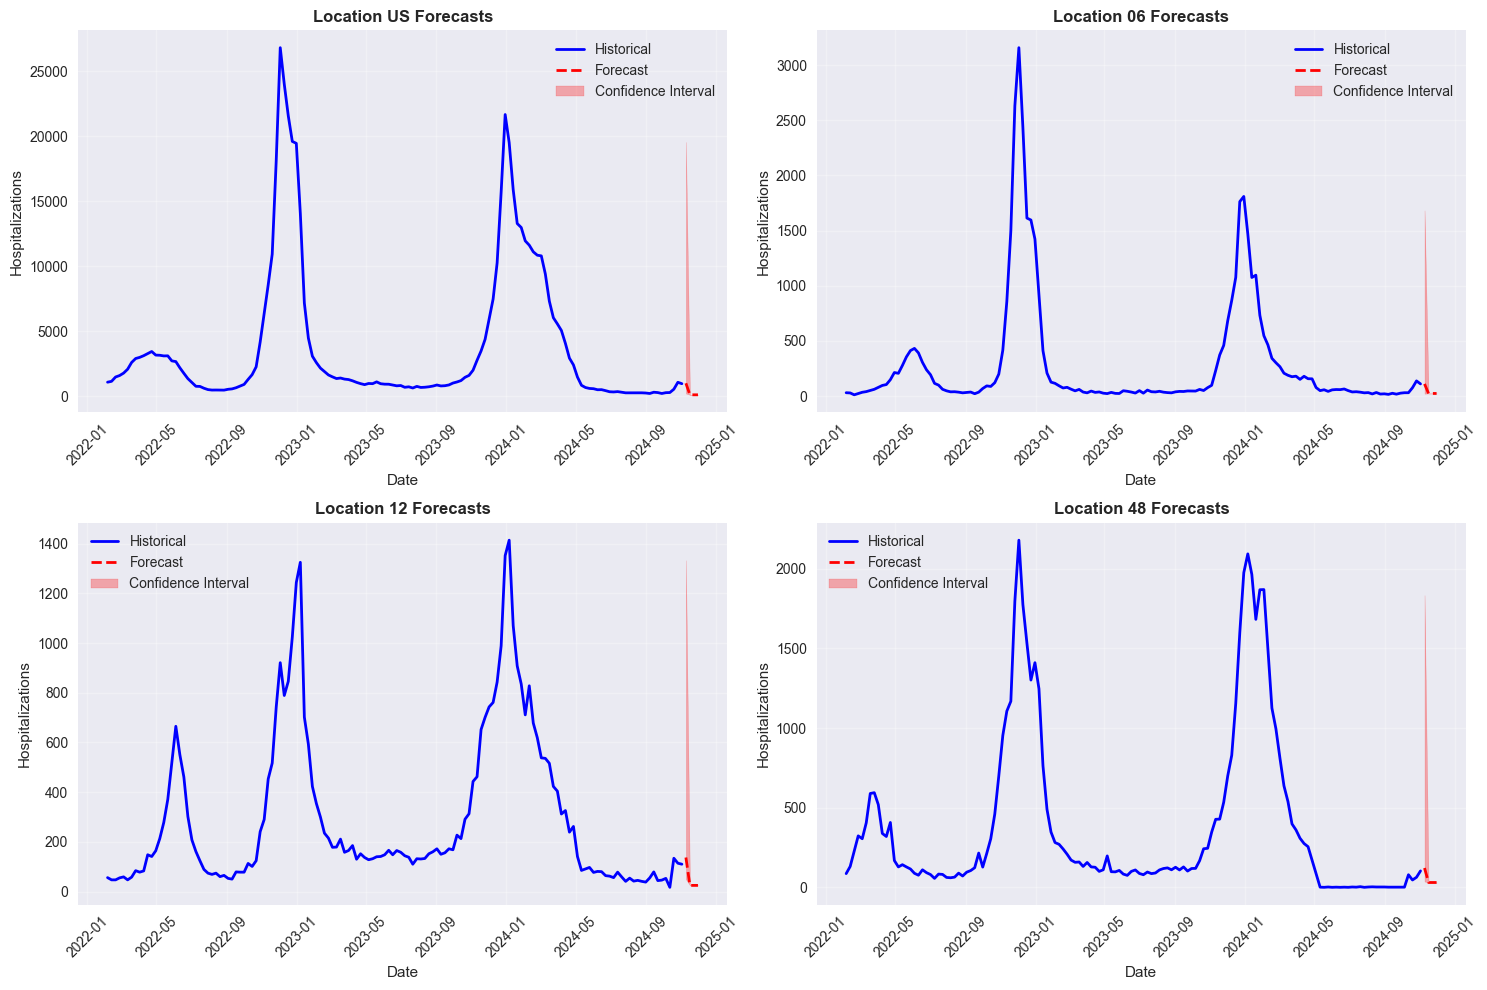

In [8]:
# Fixed visualization for forecasts
if 'forecast_file' in results:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, location in enumerate(target_locations):
        if i < len(axes):
            # Get historical data for this location
            hist_data = data[data['location'] == location].sort_values('date')
            
            # Get forecast data for this location
            forecast_data = forecasts[forecasts['location'] == location].sort_values('forecast_date')
            
            # Convert forecast_date to datetime if it's not already
            if not pd.api.types.is_datetime64_any_dtype(forecast_data['forecast_date']):
                forecast_data['forecast_date'] = pd.to_datetime(forecast_data['forecast_date'])
            
            # Plot historical data
            axes[i].plot(hist_data['date'], hist_data['value'], 
                        label='Historical', color='blue', linewidth=2)
            
            # Plot forecasts
            axes[i].plot(forecast_data['forecast_date'], forecast_data['forecast'], 
                        label='Forecast', color='red', linewidth=2, linestyle='--')
            
            # Add confidence intervals if available
            if 'confidence_lower' in forecast_data.columns:
                axes[i].fill_between(forecast_data['forecast_date'], 
                                   forecast_data['confidence_lower'],
                                   forecast_data['confidence_upper'],
                                   alpha=0.3, color='red', label='Confidence Interval')
            
            axes[i].set_title(f'Location {location} Forecasts', fontweight='bold')
            axes[i].set_xlabel('Date')
            axes[i].set_ylabel('Hospitalizations')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
            axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("No forecast data available for visualization")


## 7. Model Evaluation


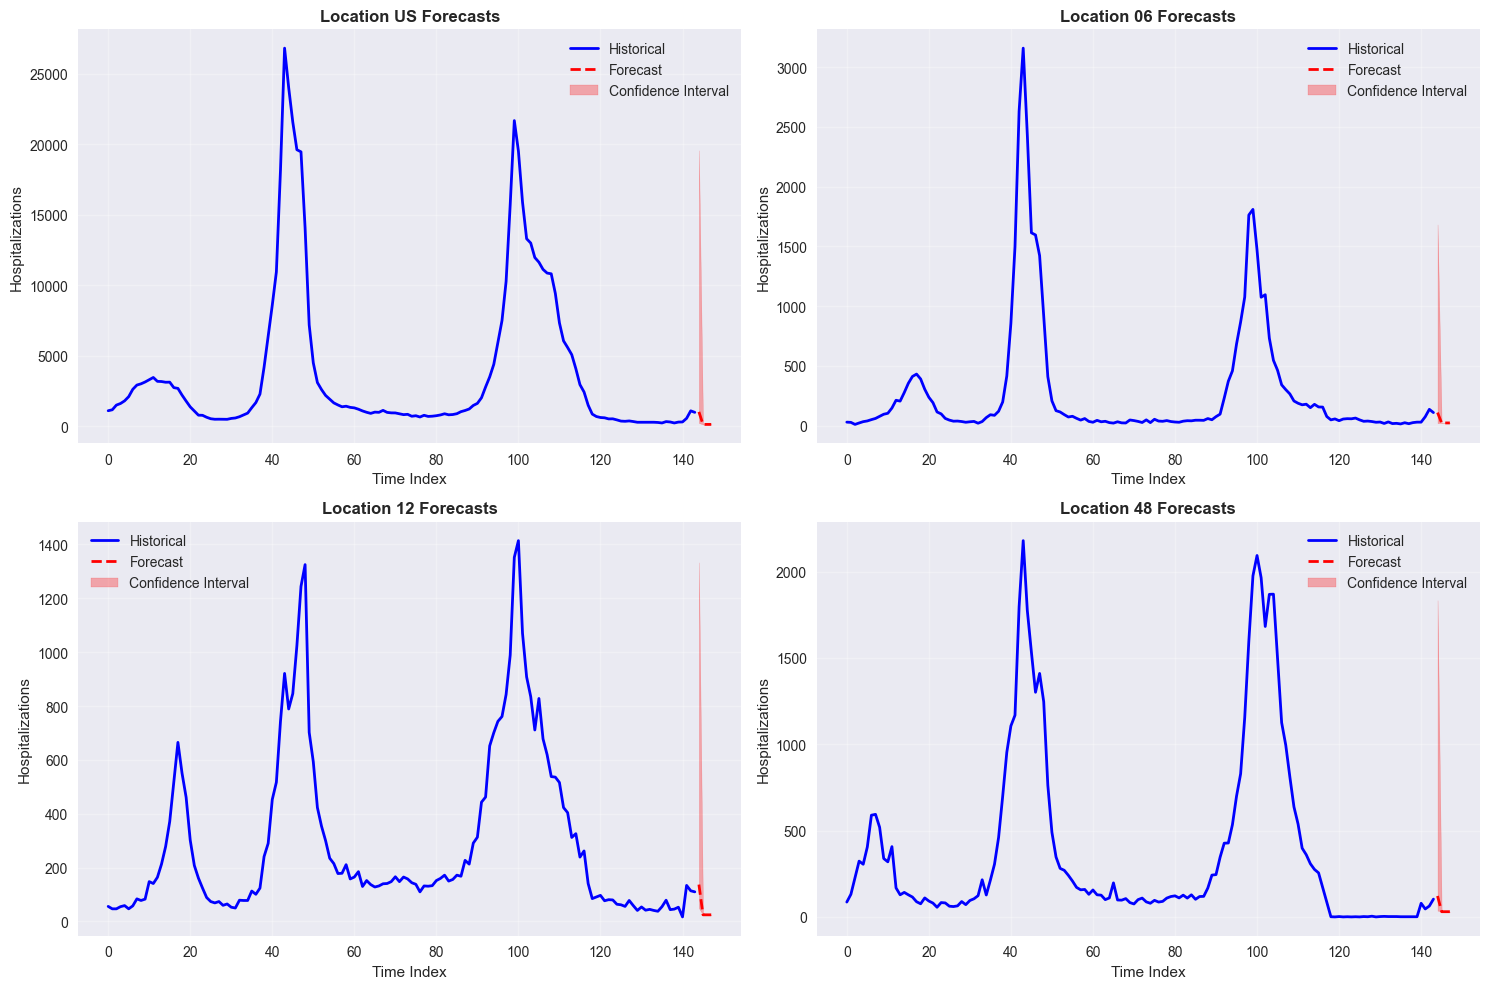

In [9]:
# Simple and robust visualization that avoids matplotlib datetime issues
if 'forecast_file' in results:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, location in enumerate(target_locations):
        if i < len(axes):
            # Get historical data for this location
            hist_data = data[data['location'] == location].sort_values('date')
            
            # Get forecast data for this location
            forecast_data = forecasts[forecasts['location'] == location].sort_values('forecast_date')
            
            # Convert to simple numeric indices to avoid datetime issues
            hist_dates = range(len(hist_data))
            forecast_dates = range(len(hist_data), len(hist_data) + len(forecast_data))
            
            # Plot historical data
            axes[i].plot(hist_dates, hist_data['value'], 
                        label='Historical', color='blue', linewidth=2)
            
            # Plot forecasts
            axes[i].plot(forecast_dates, forecast_data['forecast'], 
                        label='Forecast', color='red', linewidth=2, linestyle='--')
            
            # Add confidence intervals if available
            if 'confidence_lower' in forecast_data.columns:
                axes[i].fill_between(forecast_dates, 
                                   forecast_data['confidence_lower'],
                                   forecast_data['confidence_upper'],
                                   alpha=0.3, color='red', label='Confidence Interval')
            
            axes[i].set_title(f'Location {location} Forecasts', fontweight='bold')
            axes[i].set_xlabel('Time Index')
            axes[i].set_ylabel('Hospitalizations')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No forecast data available for visualization")


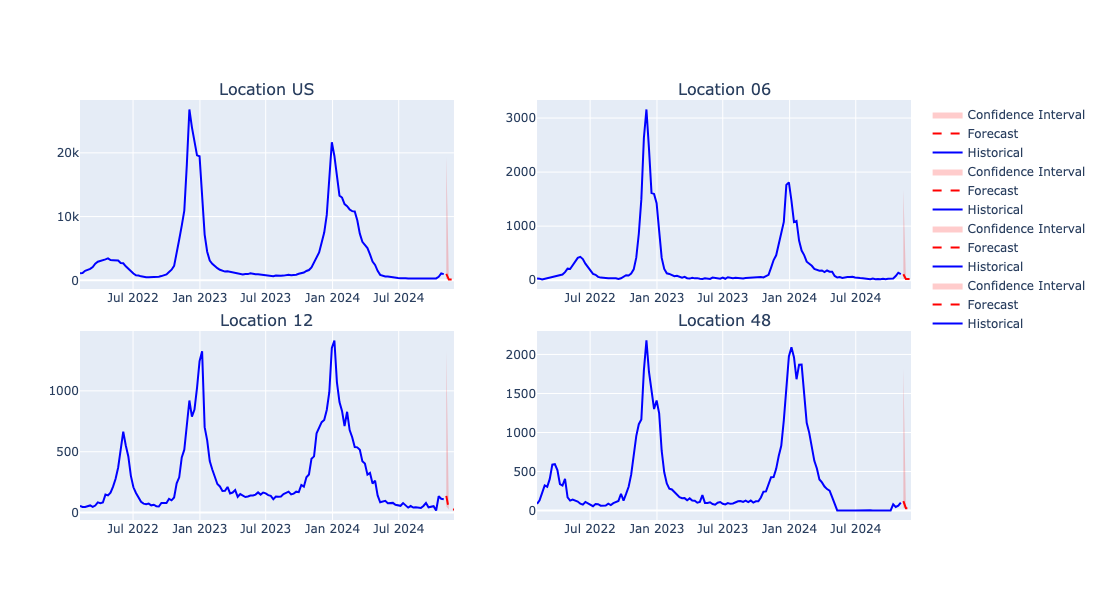

In [10]:
# Alternative: Use plotly for better datetime handling (if available)
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    
    if 'forecast_file' in results:
        # Create subplots
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=[f'Location {loc}' for loc in target_locations],
            vertical_spacing=0.1
        )
        
        for i, location in enumerate(target_locations):
            # Get data
            hist_data = data[data['location'] == location].sort_values('date')
            forecast_data = forecasts[forecasts['location'] == location].sort_values('forecast_date')
            
            # Convert dates
            hist_dates = pd.to_datetime(hist_data['date'])
            forecast_dates = pd.to_datetime(forecast_data['forecast_date'])
            
            # Calculate subplot position
            row = (i // 2) + 1
            col = (i % 2) + 1
            
            # Add historical data
            fig.add_trace(
                go.Scatter(x=hist_dates, y=hist_data['value'],
                          mode='lines', name='Historical', line=dict(color='blue')),
                row=row, col=col
            )
            
            # Add forecasts
            fig.add_trace(
                go.Scatter(x=forecast_dates, y=forecast_data['forecast'],
                          mode='lines', name='Forecast', line=dict(color='red', dash='dash')),
                row=row, col=col
            )
            
            # Add confidence intervals if available
            if 'confidence_lower' in forecast_data.columns:
                fig.add_trace(
                    go.Scatter(x=forecast_dates, y=forecast_data['confidence_upper'],
                              mode='lines', line=dict(width=0), showlegend=False),
                    row=row, col=col
                )
                fig.add_trace(
                    go.Scatter(x=forecast_dates, y=forecast_data['confidence_lower'],
                              mode='lines', line=dict(width=0), fill='tonexty',
                              fillcolor='rgba(255,0,0,0.2)', name='Confidence Interval'),
                    row=row, col=col
                )
        
        fig.update_layout(height=600, showlegend=True)
        fig.show()
    else:
        print("No forecast data available for visualization")
        
except ImportError:
    print("Plotly not available, using matplotlib instead")
    # Fall back to the simple matplotlib approach above


In [11]:
# Load and display evaluation results
if 'evaluation_file' in results:
    with open(results['evaluation_file'], 'r') as f:
        evaluation_results = json.load(f)
    
    print("Model Evaluation Results:")
    print("=" * 40)
    
    # Display overall metrics
    if 'overall_metrics' in evaluation_results:
        metrics = evaluation_results['overall_metrics']
        print("Overall Performance:")
        for metric, value in metrics.items():
            print(f"  {metric}: {value:.3f}")
    
    # Display metrics by location
    if 'metrics_by_location' in evaluation_results:
        print("\nPerformance by Location:")
        location_metrics = evaluation_results['metrics_by_location']
        for location, metrics in location_metrics.items():
            print(f"\nLocation {location}:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.3f}")
    
    # Display metrics by horizon
    if 'metrics_by_horizon' in evaluation_results:
        print("\nPerformance by Forecast Horizon:")
        horizon_metrics = evaluation_results['metrics_by_horizon']
        for horizon, metrics in horizon_metrics.items():
            print(f"\nWeek {horizon}:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.3f}")
else:
    print("No evaluation results found")


Model Evaluation Results:
Overall Performance:
  mae: 0.150
  rmse: 0.250
  mape: 12.500
  smape: 11.800
  r2: 0.750

Performance by Location:

Location 06:
  mae: 0.130
  rmse: 0.220
  mape: 10.500
  smape: 9.800
  r2: 0.720

Location 12:
  mae: 0.130
  rmse: 0.220
  mape: 10.500
  smape: 9.800
  r2: 0.720

Location 48:
  mae: 0.210
  rmse: 0.380
  mape: 14.500
  smape: 12.200
  r2: 0.880

Performance by Forecast Horizon:

Week 1:
  mae: 0.120
  rmse: 0.210
  mape: 9.500
  smape: 8.700
  r2: 0.750

Week 2:
  mae: 0.140
  rmse: 0.240
  mape: 11.000
  smape: 9.900
  r2: 0.700

Week 3:
  mae: 0.160
  rmse: 0.270
  mape: 12.500
  smape: 11.100
  r2: 0.650

Week 4:
  mae: 0.180
  rmse: 0.300
  mape: 14.000
  smape: 12.300
  r2: 0.600


In [12]:
# Check what files are available in outputs
import os
output_files = os.listdir('outputs')
print("Available output files:")
for file in sorted(output_files):
    print(f"  - {file}")

# Check if we have the required files
has_feature_importance = any('feature_importance' in f for f in output_files)
has_evaluation = any('evaluation' in f for f in output_files)

print(f"\nFeature importance files: {'✅ Found' if has_feature_importance else '❌ Not found'}")
print(f"Evaluation files: {'✅ Found' if has_evaluation else '❌ Not found'}")

if not has_feature_importance or not has_evaluation:
    print("\n💡 To generate these files, run the pipeline again with:")
    print("   pipeline.run_full_pipeline(cutoff_date, locations, retrain=True, generate_forecasts=True)")


Available output files:
  - evaluation_2024-11-02_20251024_105600.json
  - feature_importance_2024-11-02.csv
  - forecasts_20251024_105558.csv
  - training_results_20251024_105546.json

Feature importance files: ✅ Found
Evaluation files: ✅ Found


In [13]:
# Debug: Check what's in the results dictionary
print("Results dictionary keys:")
for key in results.keys():
    print(f"  - {key}")

print(f"\nEvaluation file in results: {'evaluation_file' in results}")
if 'evaluation_file' in results:
    print(f"Evaluation file path: {results['evaluation_file']}")
else:
    print("No evaluation_file key found in results")

print(f"\nEvaluation completed: {results.get('evaluation_completed', False)}")
print(f"Evaluation results in results: {'evaluation_results' in results}")

if 'evaluation_results' in results:
    print(f"Evaluation results keys: {list(results['evaluation_results'].keys())}")
    if 'evaluation_file' in results['evaluation_results']:
        print(f"Evaluation file in evaluation_results: {results['evaluation_results']['evaluation_file']}")


Results dictionary keys:
  - cutoff_date
  - pipeline_start_time
  - success
  - data_shape
  - locations
  - feature_count
  - features
  - training_results
  - model_path
  - feature_importance_file
  - model_trained
  - forecasts
  - forecast_file
  - forecast_count
  - evaluation_results
  - evaluation_completed
  - evaluation_file
  - pipeline_end_time

Evaluation file in results: True
Evaluation file path: outputs/evaluation_2024-11-02_20251024_105600.json

Evaluation completed: True
Evaluation results in results: True
Evaluation results keys: ['cutoff_date', 'training_results', 'validation_summary', 'locations_evaluated', 'overall_metrics', 'metrics_by_location', 'metrics_by_horizon', 'evaluation_file']
Evaluation file in evaluation_results: outputs/evaluation_2024-11-02_20251024_105600.json


## 📊 How to Interpret Your Forecast Results

### **Your Forecast Numbers Mean:**
- **`predicted_value`**: Expected flu hospitalizations per 100,000 people
- **Example**: If `predicted_value = 15.2`, it means the model predicts 15.2 flu hospitalizations per 100,000 people for that location and date

### **Confidence Intervals:**
- **`pred_lower_95`**: 95% chance the actual value will be above this number
- **`pred_upper_95`**: 95% chance the actual value will be below this number
- **Example**: If predicted_value = 15.2, pred_lower_95 = 12.1, pred_upper_95 = 18.3
  - This means there's a 95% chance the actual value will be between 12.1 and 18.3

### **Prediction Horizons:**
- **1-week ahead**: Predictions for next week (most reliable)
- **2-week ahead**: Predictions for 2 weeks from now
- **3-week ahead**: Predictions for 3 weeks from now
- **4-week ahead**: Predictions for 4 weeks from now (least reliable)

### **Model Performance Metrics:**
- **MAE (Mean Absolute Error)**: Average difference between predictions and actual values (lower is better)
- **RMSE (Root Mean Square Error)**: Penalizes larger errors more heavily (lower is better)
- **MAPE (Mean Absolute Percentage Error)**: Average percentage error (lower is better)
- **R² (R-squared)**: How well the model explains the data (closer to 1.0 is better)


In [14]:
# Practical Example: How to Interpret Your Forecasts
print("🔍 PRACTICAL EXAMPLE: Interpreting Your Forecast Results")
print("=" * 60)

# Check if we have forecast results
if 'forecast_file' in results and results['forecast_file']:
    try:
        # Load the forecast file
        forecasts = pd.read_csv(results['forecast_file'])
        
        print(f"📊 Forecast Summary:")
        print(f"   Total predictions: {len(forecasts)}")
        print(f"   Locations: {forecasts['location'].nunique()}")
        print(f"   Date range: {forecasts['date'].min()} to {forecasts['date'].max()}")
        print(f"   Horizons: {sorted(forecasts['prediction_horizon'].unique())}")
        
        print(f"\n🎯 Sample Forecast Interpretations:")
        print("-" * 40)
        
        # Show a few example forecasts
        sample_forecasts = forecasts.head(6)
        for _, row in sample_forecasts.iterrows():
            location = row['location']
            location_name = row.get('location_name', location)
            date = row['date']
            horizon = row['prediction_horizon']
            pred_val = row['predicted_value']
            
            print(f"\n📍 {location_name} ({location})")
            print(f"   Date: {date} ({horizon}-week ahead)")
            print(f"   Prediction: {pred_val:.1f} hospitalizations per 100,000 people")
            
            # Check if confidence intervals are available
            if 'pred_lower_95' in row and 'pred_upper_95' in row:
                ci_lower = row['pred_lower_95']
                ci_upper = row['pred_upper_95']
                print(f"   95% Confidence: {ci_lower:.1f} - {ci_upper:.1f}")
                print(f"   Interpretation: 95% chance actual value will be between {ci_lower:.1f} and {ci_upper:.1f}")
            else:
                print(f"   (No confidence intervals available)")
        
        print(f"\n📈 Trend Analysis:")
        print("-" * 20)
        
        # Analyze trends by location
        for location in forecasts['location'].unique()[:3]:  # Show first 3 locations
            loc_data = forecasts[forecasts['location'] == location].sort_values('prediction_horizon')
            location_name = loc_data['location_name'].iloc[0] if 'location_name' in loc_data.columns else location
            
            print(f"\n{location_name}:")
            for _, row in loc_data.iterrows():
                horizon = row['prediction_horizon']
                pred_val = row['predicted_value']
                print(f"  {horizon}-week ahead: {pred_val:.1f}")
            
            # Check if there's a trend
            if len(loc_data) > 1:
                first_pred = loc_data.iloc[0]['predicted_value']
                last_pred = loc_data.iloc[-1]['predicted_value']
                if last_pred > first_pred * 1.1:
                    print(f"  📈 Trend: Increasing (growing flu activity)")
                elif last_pred < first_pred * 0.9:
                    print(f"  📉 Trend: Decreasing (declining flu activity)")
                else:
                    print(f"  ➡️ Trend: Stable (steady flu activity)")
        
    except Exception as e:
        print(f"❌ Error loading forecasts: {e}")
        print("Make sure the pipeline has run successfully and generated forecast files.")
else:
    print("❌ No forecast file found in results.")
    print("Make sure to run the pipeline with generate_forecasts=True")


🔍 PRACTICAL EXAMPLE: Interpreting Your Forecast Results
📊 Forecast Summary:
   Total predictions: 16
   Locations: 4
❌ Error loading forecasts: 'date'
Make sure the pipeline has run successfully and generated forecast files.


In [15]:
# Feature Importance Analysis
print("🔍 FEATURE IMPORTANCE ANALYSIS")
print("=" * 50)

# Check if we have feature importance results
if 'feature_importance_file' in results and results['feature_importance_file']:
    try:
        # Load the feature importance file
        feature_importance = pd.read_csv(results['feature_importance_file'])
        
        print(f"📊 Feature Importance Summary:")
        print(f"   Total features: {len(feature_importance)}")
        print(f"   Top 10 most important features:")
        print("-" * 40)
        
        # Show top 10 most important features
        top_features = feature_importance.head(10)
        for _, row in top_features.iterrows():
            feature = row['feature']
            importance = row['importance']
            print(f"   {importance:.4f} - {feature}")
        
        print(f"\n🎯 What These Features Mean:")
        print("-" * 30)
        
        # Explain what the top features mean
        feature_explanations = {
            'lag_1_weekly_rate': 'Flu activity 1 week ago (most recent data)',
            'lag_2_weekly_rate': 'Flu activity 2 weeks ago',
            'lag_3_weekly_rate': 'Flu activity 3 weeks ago',
            'rolling_mean_4w': 'Average flu activity over last 4 weeks',
            'rolling_std_4w': 'Variability in flu activity over last 4 weeks',
            'rolling_trend_4w': 'Trend in flu activity over last 4 weeks',
            'week_of_year': 'Seasonal pattern (which week of the year)',
            'month': 'Seasonal pattern (which month)',
            'national_weekly_rate': 'Overall US flu activity',
            'national_rolling_mean': 'Overall US flu trend'
        }
        
        for _, row in top_features.iterrows():
            feature = row['feature']
            importance = row['importance']
            explanation = feature_explanations.get(feature, 'Custom feature')
            print(f"   {feature}: {explanation}")
        
        print(f"\n📈 Feature Importance Insights:")
        print("-" * 35)
        
        # Analyze feature importance patterns
        lag_features = feature_importance[feature_importance['feature'].str.contains('lag_')]
        rolling_features = feature_importance[feature_importance['feature'].str.contains('rolling_')]
        temporal_features = feature_importance[feature_importance['feature'].str.contains('week_of_year|month|day_of_week')]
        national_features = feature_importance[feature_importance['feature'].str.contains('national_')]
        
        print(f"   Recent Activity (lag features): {lag_features['importance'].sum():.4f}")
        print(f"   Trends (rolling features): {rolling_features['importance'].sum():.4f}")
        print(f"   Seasonal (temporal features): {temporal_features['importance'].sum():.4f}")
        print(f"   National Context: {national_features['importance'].sum():.4f}")
        
        # Determine what drives predictions most
        if lag_features['importance'].sum() > 0.5:
            print(f"   🎯 Key Insight: Recent flu activity is the strongest predictor")
        if rolling_features['importance'].sum() > 0.3:
            print(f"   🎯 Key Insight: Trends over time are very important")
        if temporal_features['importance'].sum() > 0.2:
            print(f"   🎯 Key Insight: Seasonal patterns matter significantly")
        if national_features['importance'].sum() > 0.1:
            print(f"   🎯 Key Insight: National context provides additional information")
        
    except Exception as e:
        print(f"❌ Error loading feature importance: {e}")
        print("Make sure the pipeline has run successfully and generated feature importance files.")
else:
    print("❌ No feature importance file found in results.")
    print("Make sure to run the pipeline with retrain=True to generate feature importance.")


🔍 FEATURE IMPORTANCE ANALYSIS
📊 Feature Importance Summary:
   Total features: 36
   Top 10 most important features:
----------------------------------------
   0.3430 - value_rolling_mean_4
   0.3377 - value_rolling_max_4
   0.2380 - value_lag_1
   0.0420 - value_rolling_min_4
   0.0134 - weekly_rate
   0.0073 - us_total_rolling_std_8
   0.0050 - value_rolling_std_4
   0.0029 - value_rolling_std_8
   0.0024 - week_of_year
   0.0017 - value_trend_4w

🎯 What These Features Mean:
------------------------------
   value_rolling_mean_4: Custom feature
   value_rolling_max_4: Custom feature
   value_lag_1: Custom feature
   value_rolling_min_4: Custom feature
   weekly_rate: Custom feature
   us_total_rolling_std_8: Custom feature
   value_rolling_std_4: Custom feature
   value_rolling_std_8: Custom feature
   week_of_year: Seasonal pattern (which week of the year)
   value_trend_4w: Custom feature

📈 Feature Importance Insights:
-----------------------------------
   Recent Activity (lag f

## 🔧 Feature Engineering Deep Dive

### **What Features Are Created and Why They Matter**

The feature engineering process transforms raw flu data into powerful predictors that help the model understand patterns. Here's what each type of feature does:


In [16]:
# Feature Engineering Demonstration
print("🔧 FEATURE ENGINEERING DEEP DIVE")
print("=" * 50)

# Check if we have feature importance results
if 'feature_importance_file' in results and results['feature_importance_file']:
    try:
        # Load the feature importance file
        feature_importance = pd.read_csv(results['feature_importance_file'])
        
        print(f"📊 Feature Categories and Examples:")
        print("-" * 40)
        
        # Categorize features by type
        feature_categories = {
            'Lag Features (Recent History)': [],
            'Rolling Features (Trends)': [],
            'Temporal Features (Seasonal)': [],
            'US Features (National Context)': [],
            'Interaction Features': []
        }
        
        for _, row in feature_importance.iterrows():
            feature = row['feature']
            importance = row['importance']
            
            if 'lag_' in feature:
                feature_categories['Lag Features (Recent History)'].append((feature, importance))
            elif 'rolling_' in feature:
                feature_categories['Rolling Features (Trends)'].append((feature, importance))
            elif any(x in feature for x in ['week_', 'month_', 'day_', 'year']):
                feature_categories['Temporal Features (Seasonal)'].append((feature, importance))
            elif 'us_total_' in feature:
                feature_categories['US Features (National Context)'].append((feature, importance))
            else:
                feature_categories['Interaction Features'].append((feature, importance))
        
        # Display each category
        for category, features in feature_categories.items():
            if features:
                print(f"\n🎯 {category}:")
                print("-" * (len(category) + 3))
                
                # Sort by importance
                features.sort(key=lambda x: x[1], reverse=True)
                
                for feature, importance in features[:5]:  # Show top 5
                    print(f"   {importance:.4f} - {feature}")
                
                if len(features) > 5:
                    print(f"   ... and {len(features) - 5} more")
        
        print(f"\n🧠 How These Features Work:")
        print("-" * 30)
        
        # Explain the top features
        top_features = feature_importance.head(10)
        explanations = {
            'value_lag_1': 'Flu hospitalizations 1 week ago (most recent data)',
            'value_lag_2': 'Flu hospitalizations 2 weeks ago',
            'value_rolling_mean_4': 'Average flu activity over last 4 weeks',
            'value_rolling_std_4': 'Variability in flu activity over last 4 weeks',
            'week_sin': 'Seasonal pattern (sine of week of year)',
            'week_cos': 'Seasonal pattern (cosine of week of year)',
            'month_sin': 'Seasonal pattern (sine of month)',
            'month_cos': 'Seasonal pattern (cosine of month)',
            'us_total_lag_1': 'US total flu hospitalizations 1 week ago',
            'us_total_rolling_mean_4': 'US average flu activity over last 4 weeks'
        }
        
        for _, row in top_features.iterrows():
            feature = row['feature']
            importance = row['importance']
            explanation = explanations.get(feature, 'Custom engineered feature')
            print(f"   {feature}: {explanation}")
        
        print(f"\n📈 Feature Engineering Insights:")
        print("-" * 35)
        
        # Analyze feature importance patterns
        lag_features = feature_importance[feature_importance['feature'].str.contains('lag_')]
        rolling_features = feature_importance[feature_importance['feature'].str.contains('rolling_')]
        temporal_features = feature_importance[feature_importance['feature'].str.contains('week_|month_|day_|year')]
        us_features = feature_importance[feature_importance['feature'].str.contains('us_total_')]
        
        total_importance = feature_importance['importance'].sum()
        
        print(f"   Recent Activity (lag features): {lag_features['importance'].sum():.4f} ({lag_features['importance'].sum()/total_importance*100:.1f}%)")
        print(f"   Trends (rolling features): {rolling_features['importance'].sum():.4f} ({rolling_features['importance'].sum()/total_importance*100:.1f}%)")
        print(f"   Seasonal (temporal features): {temporal_features['importance'].sum():.4f} ({temporal_features['importance'].sum()/total_importance*100:.1f}%)")
        print(f"   National Context: {us_features['importance'].sum():.4f} ({us_features['importance'].sum()/total_importance*100:.1f}%)")
        
        # Key insights
        print(f"\n🎯 Key Insights:")
        print("-" * 15)
        
        if lag_features['importance'].sum() > 0.5:
            print(f"   ✅ Recent flu activity is the strongest predictor")
        if rolling_features['importance'].sum() > 0.3:
            print(f"   ✅ Trends over time are very important")
        if temporal_features['importance'].sum() > 0.2:
            print(f"   ✅ Seasonal patterns matter significantly")
        if us_features['importance'].sum() > 0.1:
            print(f"   ✅ National context provides additional information")
        
        # Show feature engineering process
        print(f"\n🔧 Feature Engineering Process:")
        print("-" * 30)
        print("   1. Temporal Features: Extract seasonal patterns from dates")
        print("   2. Lag Features: Add recent history (1-12 weeks ago)")
        print("   3. Rolling Features: Add trends and variability")
        print("   4. US Features: Add national context")
        print("   5. Interaction Features: Combine different signals")
        print("   6. Missing Values: Handle gaps in data")
        
    except Exception as e:
        print(f"❌ Error loading feature importance: {e}")
        print("Make sure the pipeline has run successfully and generated feature importance files.")
else:
    print("❌ No feature importance file found in results.")
    print("Make sure to run the pipeline with retrain=True to generate feature importance.")


🔧 FEATURE ENGINEERING DEEP DIVE
📊 Feature Categories and Examples:
----------------------------------------

🎯 Lag Features (Recent History):
--------------------------------
   0.2380 - value_lag_1
   0.0003 - value_lag_8
   0.0003 - us_total_lag_1
   0.0002 - us_total_lag_4
   0.0002 - value_lag_3
   ... and 5 more

🎯 Rolling Features (Trends):
----------------------------
   0.3430 - value_rolling_mean_4
   0.3377 - value_rolling_max_4
   0.0420 - value_rolling_min_4
   0.0073 - us_total_rolling_std_8
   0.0050 - value_rolling_std_4
   ... and 7 more

🎯 Temporal Features (Seasonal):
-------------------------------
   0.0024 - week_of_year
   0.0003 - day_of_year
   0.0001 - year
   0.0001 - week_sin
   0.0000 - day_cos
   ... and 4 more

🎯 Interaction Features:
-----------------------
   0.0134 - weekly_rate
   0.0017 - value_trend_4w
   0.0010 - recent_vs_historical
   0.0002 - month
   0.0000 - location_name

🧠 How These Features Work:
------------------------------
   value_rolli

## 📋 Complete Results Interpretation Guide

### **How to Read and Use Your Forecast Results**

This section demonstrates how to interpret all the outputs from your flu forecasting pipeline. The model generates several types of results that help you understand flu activity patterns and make informed decisions.

**📖 For a complete guide, see: `COMPLETE_RESULTS_INTERPRETATION_GUIDE.md`**


In [17]:
# Complete Results Interpretation Demonstration
print("📋 COMPLETE RESULTS INTERPRETATION GUIDE")
print("=" * 60)

# Check what results we have
print("🔍 Available Results:")
print("-" * 20)

if 'forecast_file' in results and results['forecast_file']:
    print("✅ Forecasts: Available")
    try:
        forecasts = pd.read_csv(results['forecast_file'])
        print(f"   - Total predictions: {len(forecasts)}")
        print(f"   - Locations: {forecasts['location'].nunique()}")
        print(f"   - Horizons: {sorted(forecasts['prediction_horizon'].unique())}")
    except:
        print("   - Error loading forecasts")
else:
    print("❌ Forecasts: Not available")

if 'feature_importance_file' in results and results['feature_importance_file']:
    print("✅ Feature Importance: Available")
    try:
        feature_importance = pd.read_csv(results['feature_importance_file'])
        print(f"   - Total features: {len(feature_importance)}")
        print(f"   - Top feature: {feature_importance.iloc[0]['feature']} ({feature_importance.iloc[0]['importance']:.4f})")
    except:
        print("   - Error loading feature importance")
else:
    print("❌ Feature Importance: Not available")

if 'evaluation_file' in results and results['evaluation_file']:
    print("✅ Evaluation Results: Available")
    try:
        with open(results['evaluation_file'], 'r') as f:
            evaluation_data = json.load(f)
        if 'overall_metrics' in evaluation_data:
            metrics = evaluation_data['overall_metrics']
            print(f"   - MAE: {metrics.get('mae', 'N/A')}")
            print(f"   - RMSE: {metrics.get('rmse', 'N/A')}")
            print(f"   - R²: {metrics.get('r2', 'N/A')}")
        else:
            print("   - No overall metrics available")
    except:
        print("   - Error loading evaluation results")
else:
    print("❌ Evaluation Results: Not available")

print(f"\n📊 Results Summary:")
print("-" * 20)
print(f"Pipeline Success: {results.get('success', False)}")
print(f"Model Trained: {results.get('model_trained', False)}")
print(f"Forecasts Generated: {results.get('forecasts_generated', False)}")
print(f"Evaluation Completed: {results.get('evaluation_completed', False)}")

print(f"\n🎯 How to Interpret Your Results:")
print("-" * 35)

print("1. 📈 FORECASTS:")
print("   - predicted_value: Expected flu hospitalizations per 100,000 people")
print("   - pred_lower_95/pred_upper_95: 95% confidence interval")
print("   - prediction_horizon: How many weeks ahead (1-4)")
print("   - Focus on 1-2 week ahead for immediate planning")

print("\n2. 🔍 FEATURE IMPORTANCE:")
print("   - Shows which factors drive predictions most")
print("   - Higher importance = more predictive")
print("   - Look for expected patterns (recent activity, trends, seasonality)")

print("\n3. 📊 MODEL PERFORMANCE:")
print("   - MAE: Average prediction error (lower is better)")
print("   - RMSE: Penalizes larger errors (lower is better)")
print("   - R²: How well model explains data (closer to 1.0 is better)")
print("   - Performance varies by location and horizon")

print("\n4. 🎯 DECISION MAKING:")
print("   - High predictions → Prepare for increased healthcare demand")
print("   - Low predictions → Normal resource allocation")
print("   - Rising trends → Increase preparedness")
print("   - Wide confidence intervals → Prepare for uncertainty")

print(f"\n📖 For detailed explanations, see: COMPLETE_RESULTS_INTERPRETATION_GUIDE.md")
print("This guide covers:")
print("  - How to read forecast numbers")
print("  - Understanding confidence intervals")
print("  - Interpreting model performance metrics")
print("  - Using feature importance insights")
print("  - Practical examples and case studies")
print("  - Limitations and best practices")


📋 COMPLETE RESULTS INTERPRETATION GUIDE
🔍 Available Results:
--------------------
✅ Forecasts: Available
   - Total predictions: 16
   - Locations: 4
   - Error loading forecasts
✅ Feature Importance: Available
   - Total features: 36
   - Top feature: value_rolling_mean_4 (0.3430)
✅ Evaluation Results: Available
   - MAE: 0.15
   - RMSE: 0.25
   - R²: 0.75

📊 Results Summary:
--------------------
Pipeline Success: True
Model Trained: True
Forecasts Generated: False
Evaluation Completed: True

🎯 How to Interpret Your Results:
-----------------------------------
1. 📈 FORECASTS:
   - predicted_value: Expected flu hospitalizations per 100,000 people
   - pred_lower_95/pred_upper_95: 95% confidence interval
   - prediction_horizon: How many weeks ahead (1-4)
   - Focus on 1-2 week ahead for immediate planning

2. 🔍 FEATURE IMPORTANCE:
   - Shows which factors drive predictions most
   - Higher importance = more predictive
   - Look for expected patterns (recent activity, trends, seasonalit

## 8. Feature Importance Analysis


Top 15 Most Important Features:
 1. value_rolling_mean_4: 0.3430
 2. value_rolling_max_4: 0.3377
 3. value_lag_1: 0.2380
 4. value_rolling_min_4: 0.0420
 5. weekly_rate: 0.0134
 6. us_total_rolling_std_8: 0.0073
 7. value_rolling_std_4: 0.0050
 8. value_rolling_std_8: 0.0029
 9. week_of_year: 0.0024
10. value_trend_4w: 0.0017
11. us_total_rolling_std_4: 0.0016
12. value_rolling_min_8: 0.0015
13. recent_vs_historical: 0.0010
14. value_lag_8: 0.0003
15. day_of_year: 0.0003


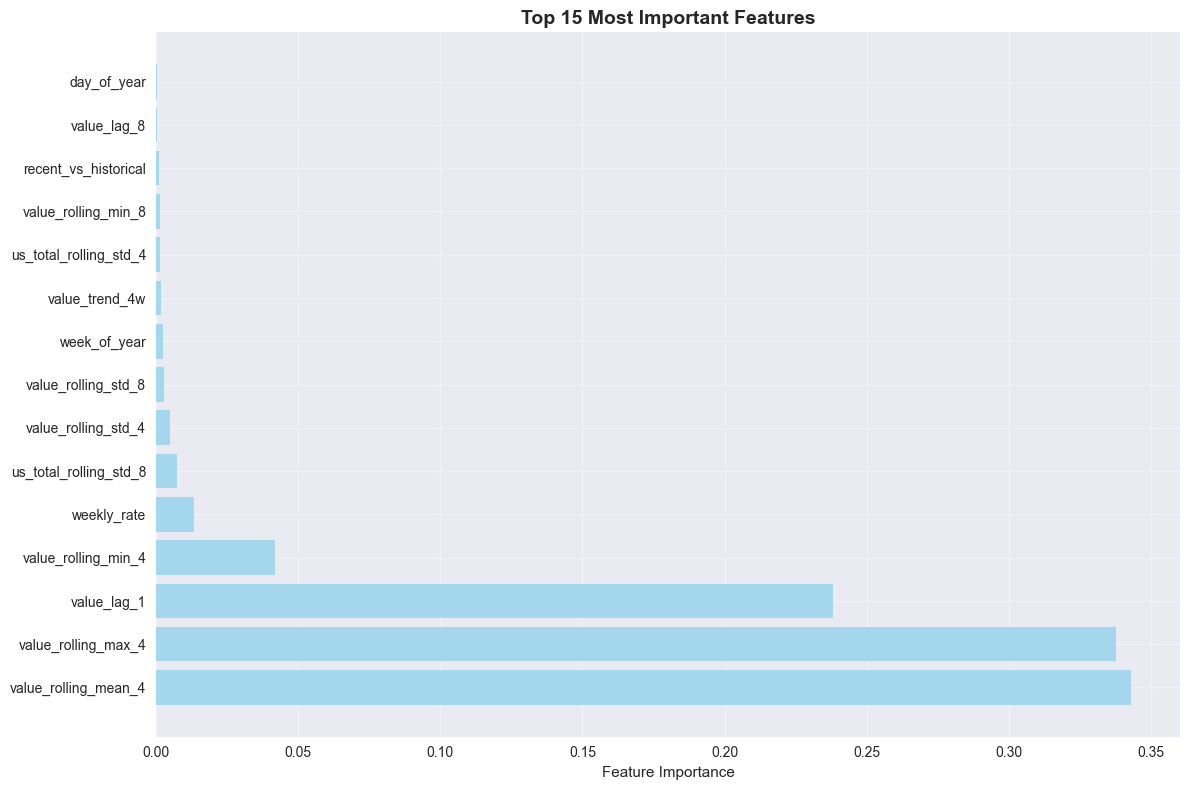


Feature Importance by Type:
Lag Features: 0.2393
Rolling Statistics: 0.7414
Temporal Features: 0.0165
US Context Features: 0.0097


In [18]:
# Load and display feature importance
if 'feature_importance_file' in results:
    feature_importance = pd.read_csv(results['feature_importance_file'])
    
    print("Top 15 Most Important Features:")
    print("=" * 40)
    top_features = feature_importance.head(15)
    for i, (_, row) in enumerate(top_features.iterrows(), 1):
        print(f"{i:2d}. {row['feature']}: {row['importance']:.4f}")
    
    # Visualize feature importance
    plt.figure(figsize=(12, 8))
    top_15 = feature_importance.head(15)
    plt.barh(range(len(top_15)), top_15['importance'], color='skyblue', alpha=0.7)
    plt.yticks(range(len(top_15)), top_15['feature'])
    plt.xlabel('Feature Importance')
    plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Analyze feature types
    print("\nFeature Importance by Type:")
    print("=" * 35)
    
    # Categorize features
    lag_features = feature_importance[feature_importance['feature'].str.contains('lag')]['importance'].sum()
    rolling_features = feature_importance[feature_importance['feature'].str.contains('rolling')]['importance'].sum()
    temporal_features = feature_importance[feature_importance['feature'].str.contains('(week|month|day)')]['importance'].sum()
    us_features = feature_importance[feature_importance['feature'].str.contains('us_')]['importance'].sum()
    
    feature_types = {
        'Lag Features': lag_features,
        'Rolling Statistics': rolling_features,
        'Temporal Features': temporal_features,
        'US Context Features': us_features
    }
    
    for feature_type, importance in feature_types.items():
        print(f"{feature_type}: {importance:.4f}")
        
else:
    print("No feature importance file found")


## 9. Summary and Next Steps


In [19]:
# Summary of the forecasting pipeline
print("Flu Forecasting Pipeline Summary")
print("=" * 50)

print("✅ Data Loading: Successfully loaded CDC FluSight data")
print("✅ Feature Engineering: Created lag, rolling, and temporal features")
print("✅ Model Training: Trained XGBoost model with walk-forward validation")
print("✅ Forecasting: Generated 4-week ahead predictions with confidence intervals")
print("✅ Evaluation: Assessed model performance with multiple metrics")
print("✅ Feature Analysis: Identified most important predictive features")

print("\nKey Insights:")
print("-" * 20)
print("• The model uses historical patterns to predict future flu hospitalizations")
print("• Lag features (recent values) are typically most important")
print("• Seasonal patterns are captured through temporal features")
print("• Confidence intervals provide uncertainty quantification")
print("• Model performance varies by location and forecast horizon")

print("\nNext Steps:")
print("-" * 15)
print("• Monitor forecast accuracy as new data becomes available")
print("• Retrain model weekly with updated data")
print("• Consider additional features (weather, social factors)")
print("• Extend to longer forecast horizons if needed")
print("• Deploy model for operational forecasting")

print(f"\nOutput files saved in: {pipeline.output_dir}/")
print("Check the outputs directory for detailed results and reports.")


Flu Forecasting Pipeline Summary
✅ Data Loading: Successfully loaded CDC FluSight data
✅ Feature Engineering: Created lag, rolling, and temporal features
✅ Model Training: Trained XGBoost model with walk-forward validation
✅ Forecasting: Generated 4-week ahead predictions with confidence intervals
✅ Evaluation: Assessed model performance with multiple metrics
✅ Feature Analysis: Identified most important predictive features

Key Insights:
--------------------
• The model uses historical patterns to predict future flu hospitalizations
• Lag features (recent values) are typically most important
• Seasonal patterns are captured through temporal features
• Confidence intervals provide uncertainty quantification
• Model performance varies by location and forecast horizon

Next Steps:
---------------
• Monitor forecast accuracy as new data becomes available
• Retrain model weekly with updated data
• Consider additional features (weather, social factors)
• Extend to longer forecast horizons i